# Научно-исследовательская работа: Анализ взаимосвязи физических показателей у взрослого населения

In [15]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)

print("Библиотеки загружены.")



Библиотеки загружены.


# 1. Загрузка и объединение данных

In [16]:
# Загрузка файлов
demo = pd.read_csv('demographic.csv')
exam = pd.read_csv('examination.csv')
quest = pd.read_csv('questionnaire.csv')

# Объединение по уникальному ID участника (SEQN)
df = demo[['SEQN', 'RIAGENDR', 'RIDAGEYR']].copy()
df = df.merge(exam[['SEQN', 'BMXBMI']], on='SEQN', how='inner')
df = df.merge(quest[['SEQN', 'PAQ650', 'PAQ635', 'SLD010H']], on='SEQN', how='inner')

print(f"Данные загружены. Всего строк: {len(df)}")
df.head()

Данные загружены. Всего строк: 9813


,SEQN,RIAGENDR,RIDAGEYR,BMXBMI,PAQ650,PAQ635,SLD010H
0,73557,1,69,26.7,2.0,2.0,7.0
1,73558,1,54,28.6,2.0,2.0,9.0
2,73559,1,72,28.9,2.0,2.0,8.0
3,73560,1,9,17.1,NaN,NaN,NaN
4,73561,2,73,19.7,2.0,2.0,9.0


# 2. Очистка данных

In [18]:
# Удаление строк с пропусками
df = df.dropna(subset=['PAQ650', 'PAQ635', 'SLD010H', 'BMXBMI'])

# Удаление недостоверных кодов (9 = "Не знаю")
df = df[(df['PAQ650'] != 9) & (df['PAQ635'] != 9)]

# Фильтрация по возрасту (взрослые 20–70 лет)
df = df[(df['RIDAGEYR'] >= 20) & (df['RIDAGEYR'] <= 70)]

# Фильтрация ИМТ (устранение выбросов)
df = df[(df['BMXBMI'] >= 12) & (df['BMXBMI'] <= 60)]

# Фильтрация сна (реалистичные значения)
df = df[(df['SLD010H'] >= 3) & (df['SLD010H'] <= 12)]

print(f"Строк после очистки: {len(df)}")

Строк после очистки: 4709


# 3. Кодировка переменных

In [19]:
# Уровень ежедневной активности (PAQ650)
df['Activity'] = df['PAQ650'].map({
    1: 'Sedentary',
    2: 'Light'
})

# Уровень сидячего времени (PAQ635)
df['Sitting'] = df['PAQ635'].map({
    1: 'Low',
    2: 'Medium'
})

# Пол
df['Gender'] = df['RIAGENDR'].map({
    1: 'Male',
    2: 'Female'
})

# Возрастные группы
df['AgeGroup'] = pd.cut(df['RIDAGEYR'], bins=[20, 40, 60, 70], labels=['20-39', '40-59', '60-70'])

# Группы сна
df['SleepGroup'] = pd.cut(df['SLD010H'], bins=[0, 6, 8, 12], labels=['<6h', '7-8h', '>8h'])

print("Переменные закодированы.")


Переменные закодированы.


 # 4. Визуализация: Гистограммы и KDE-плотности

In [ ]:
# Гистограмма ИМТ (общая)
plt.figure(figsize=(10, 5))
sns.histplot(df['BMXBMI'], kde=True, color='blue')
plt.title('Распределение ИМТ (вся выборка)')
plt.xlabel('ИМТ')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

# KDE-плотность ИМТ по полу
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='BMXBMI', hue='Gender', fill=True, alpha=0.5)
plt.title('Плотность распределения ИМТ по полу')
plt.xlabel('ИМТ')
plt.ylabel('Плотность')
plt.grid(True)
plt.show()

# Гистограмма сна
plt.figure(figsize=(10, 5))
sns.histplot(df['SLD010H'], kde=True, color='green')
plt.title('Распределение продолжительности сна')
plt.xlabel('Часы сна')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

## 5. Анализ и проверка гипотез (с множеством графиков)

# Гипотеза H1: Сидячее время vs ИМТ

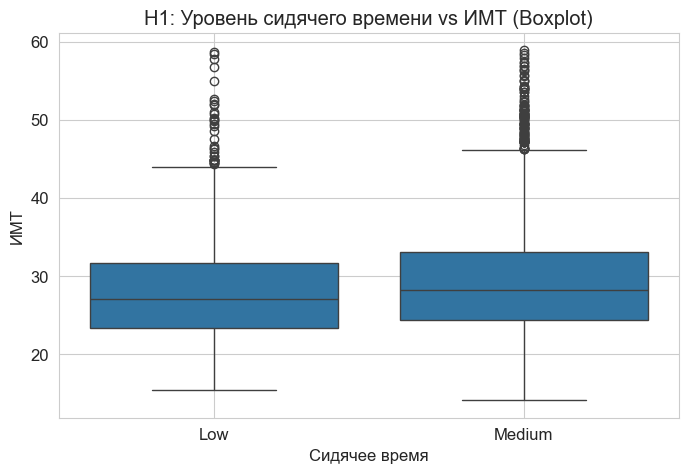

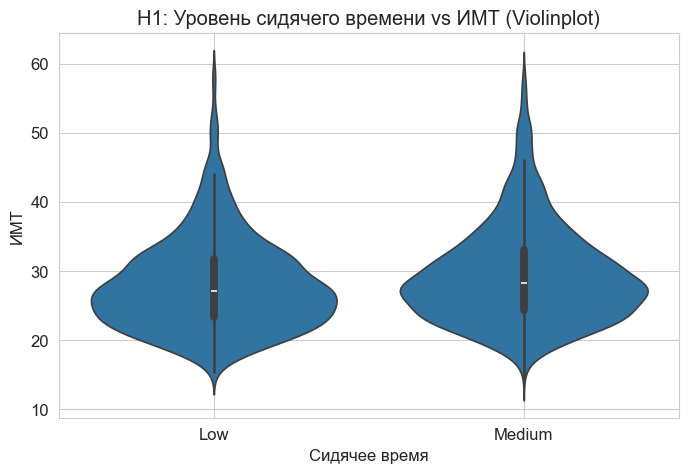

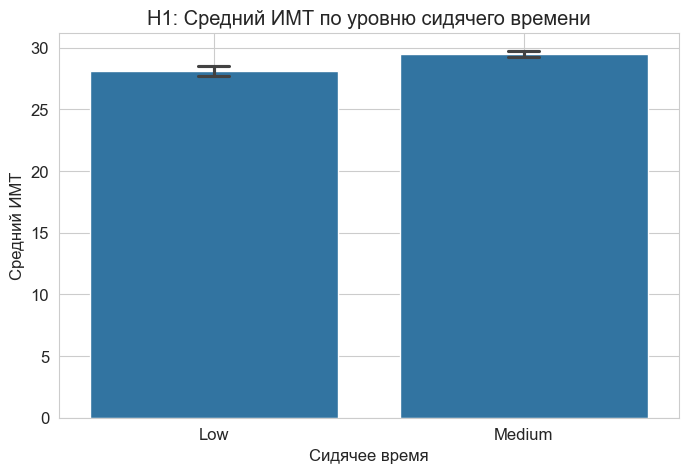

              mean       std  count
Sitting                            
Low      28.095469  6.751173   1258
Medium   29.484961  7.129147   3451


In [20]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sitting', y='BMXBMI', order=['Low', 'Medium'])
plt.title('H1: Уровень сидячего времени vs ИМТ (Boxplot)')
plt.xlabel('Сидячее время')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# Violinplot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Sitting', y='BMXBMI', order=['Low', 'Medium'])
plt.title('H1: Уровень сидячего времени vs ИМТ (Violinplot)')
plt.xlabel('Сидячее время')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# Barplot с ошибками
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Sitting', y='BMXBMI', order=['Low', 'Medium'], capsize=0.1)
plt.title('H1: Средний ИМТ по уровню сидячего времени')
plt.xlabel('Сидячее время')
plt.ylabel('Средний ИМТ')
plt.grid(True)
plt.show()

# Статистика
print(df.groupby('Sitting')['BMXBMI'].agg(['mean', 'std', 'count']))

# Гипотеза H2: Пол и возраст vs ИМТ

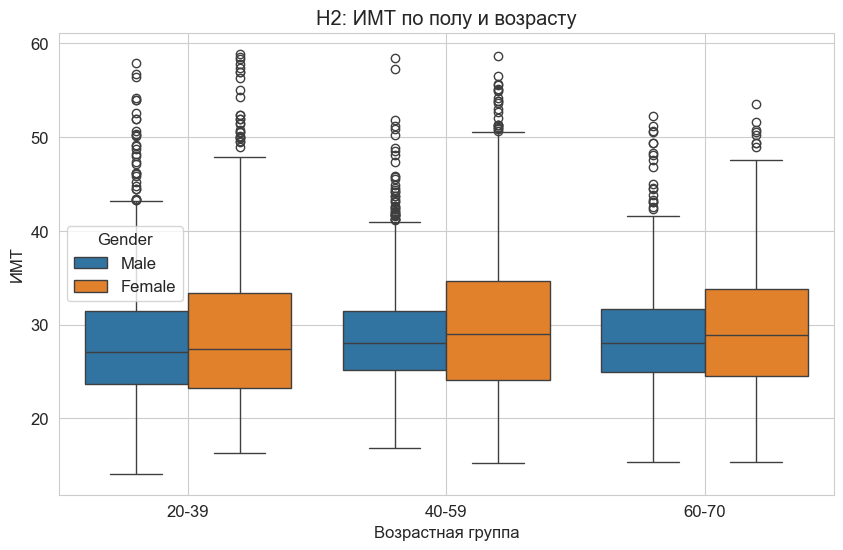

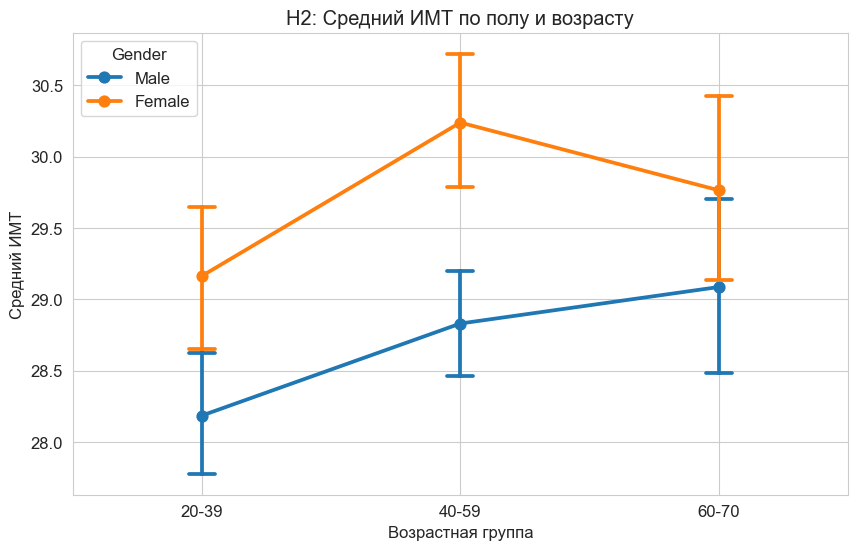

                      mean  count
Gender AgeGroup                  
Female 20-39     29.164792    960
       40-59     30.239676    988
       60-70     29.765265    452
Male   20-39     28.186637    898
       40-59     28.831362    896
       60-70     29.087073    410


In [22]:
# Boxplot по полу и возрасту
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='AgeGroup', y='BMXBMI', hue='Gender')
plt.title('H2: ИМТ по полу и возрасту')
plt.xlabel('Возрастная группа')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# Pointplot для наглядности средних значений
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='AgeGroup', y='BMXBMI', hue='Gender', capsize=0.1)
plt.title('H2: Средний ИМТ по полу и возрасту')
plt.xlabel('Возрастная группа')
plt.ylabel('Средний ИМТ')
plt.grid(True)
plt.show()

# Статистика
print(df.groupby(['Gender', 'AgeGroup'])['BMXBMI'].agg(['mean', 'count']))

# Гипотеза H3: Активность vs ИМТ (по возрасту)

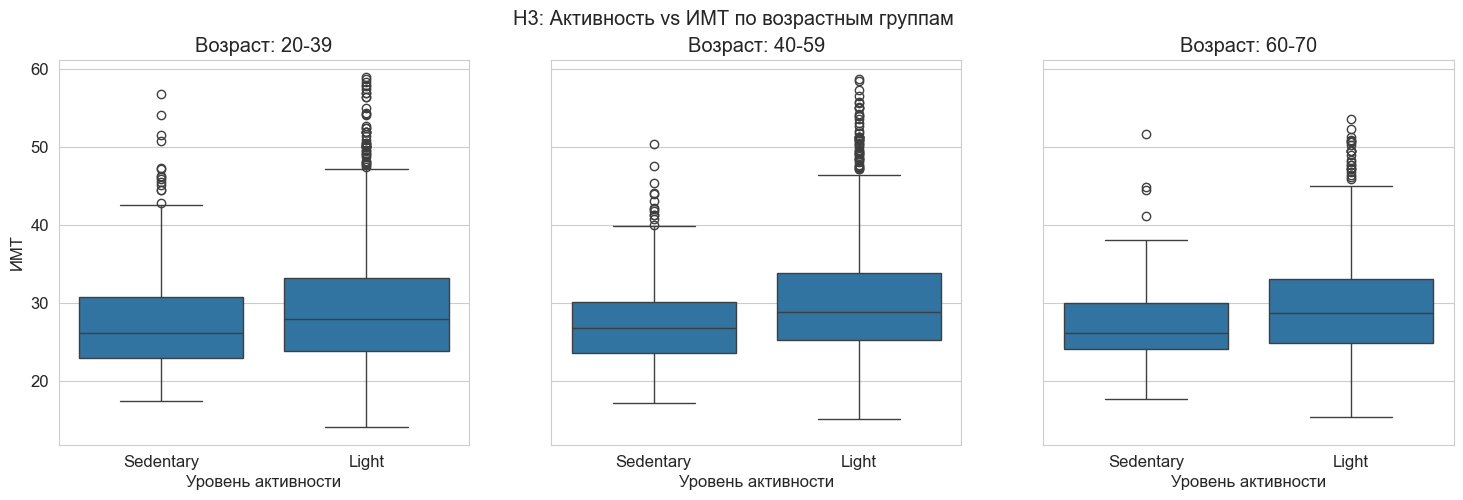

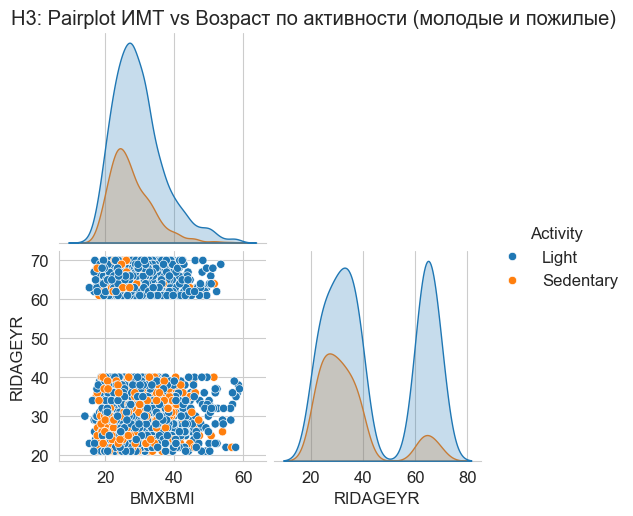

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

age_groups = ['20-39', '40-59', '60-70']
for i, age in enumerate(age_groups):
    subset = df[df['AgeGroup'] == age]
    sns.boxplot(data=subset, x='Activity', y='BMXBMI', ax=axes[i], order=['Sedentary', 'Light'])
    axes[i].set_title(f'Возраст: {age}')
    axes[i].set_xlabel('Уровень активности')
    if i == 0:
        axes[i].set_ylabel('ИМТ')
    else:
        axes[i].set_ylabel('')

plt.suptitle('H3: Активность vs ИМТ по возрастным группам')
plt.show()

# Pairplot для трёх переменных
g = sns.pairplot(df[df['AgeGroup'].isin(['20-39', '60-70'])],
                 vars=['BMXBMI', 'RIDAGEYR'],
                 hue='Activity',
                 corner=True)
g.fig.suptitle('H3: Pairplot ИМТ vs Возраст по активности (молодые и пожилые)', y=1.02)
plt.show()

# Гипотеза H4: Сон и активность vs ИМТ

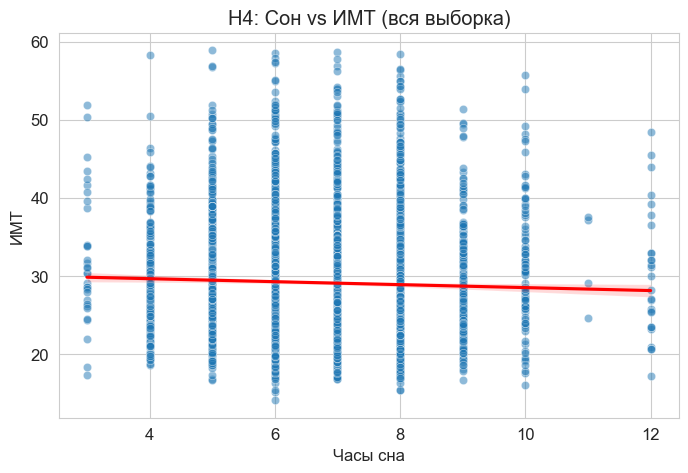

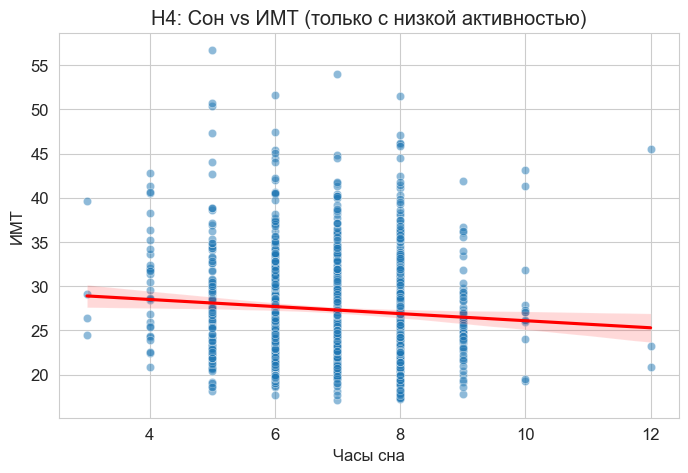

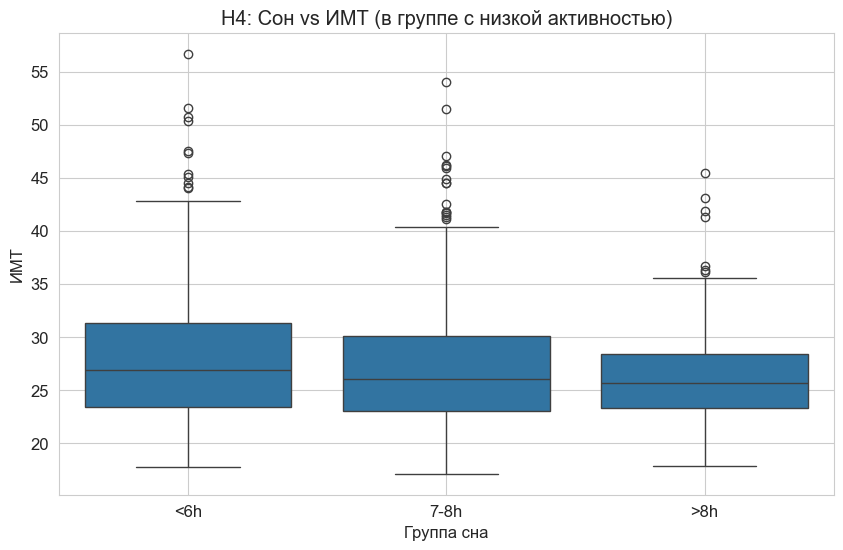

                 mean  count
SleepGroup                  
<6h         27.912472    449
7-8h        27.045354    635
>8h         26.677027     74


In [24]:
# Scatterplot с регрессией (сон vs ИМТ)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='SLD010H', y='BMXBMI', alpha=0.5)
sns.regplot(data=df, x='SLD010H', y='BMXBMI', scatter=False, color='red')
plt.title('H4: Сон vs ИМТ (вся выборка)')
plt.xlabel('Часы сна')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# Scatterplot для группы с низкой активностью
df_low_activity = df[df['Activity'] == 'Sedentary']
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_low_activity, x='SLD010H', y='BMXBMI', alpha=0.5)
sns.regplot(data=df_low_activity, x='SLD010H', y='BMXBMI', scatter=False, color='red')
plt.title('H4: Сон vs ИМТ (только с низкой активностью)')
plt.xlabel('Часы сна')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# Boxplot по группам сна и активности
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_low_activity, x='SleepGroup', y='BMXBMI', order=['<6h', '7-8h', '>8h'])
plt.title('H4: Сон vs ИМТ (в группе с низкой активностью)')
plt.xlabel('Группа сна')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# Статистика
print(df_low_activity.groupby('SleepGroup')['BMXBMI'].agg(['mean', 'count']))

# Гипотеза H5: Дисперсия ИМТ по уровню активности

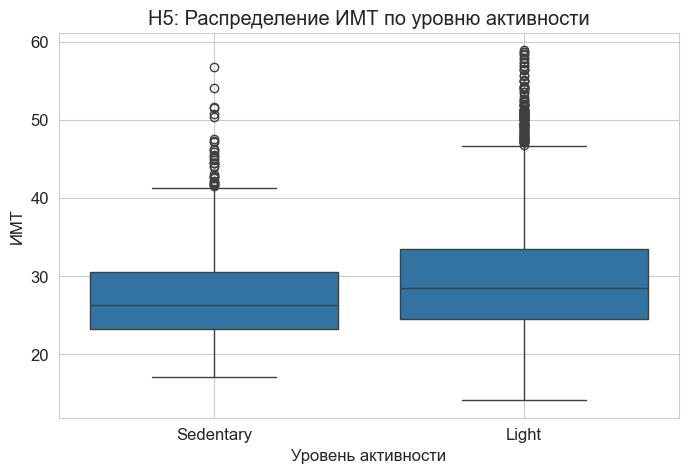

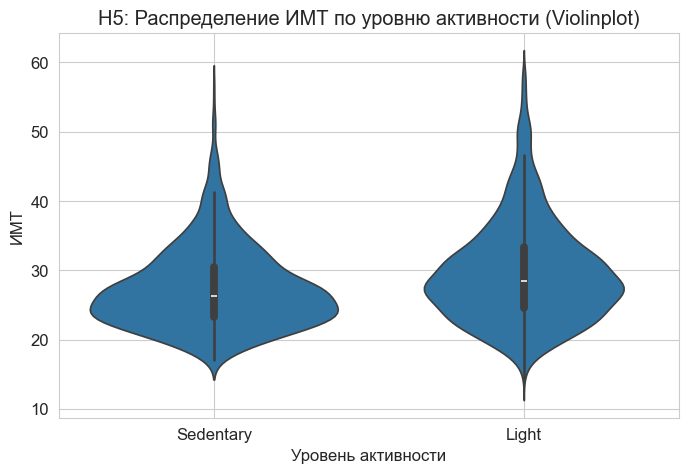

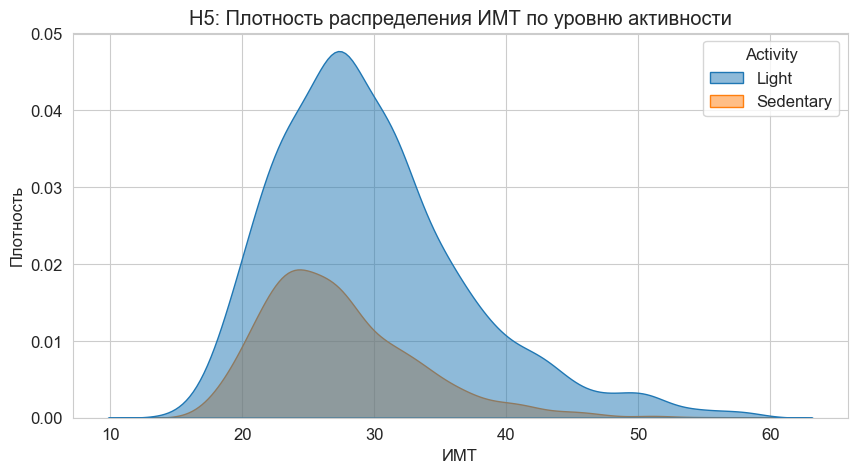

Дисперсия ИМТ (Sedentary): 34.58
Дисперсия ИМТ (Light): 53.43


In [27]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Activity', y='BMXBMI', order=['Sedentary', 'Light'])
plt.title('H5: Распределение ИМТ по уровню активности')
plt.xlabel('Уровень активности')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# Violinplot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Activity', y='BMXBMI', order=['Sedentary', 'Light'])
plt.title('H5: Распределение ИМТ по уровню активности (Violinplot)')
plt.xlabel('Уровень активности')
plt.ylabel('ИМТ')
plt.grid(True)
plt.show()

# KDE-плотности
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='BMXBMI', hue='Activity', fill=True, alpha=0.5)
plt.title('H5: Плотность распределения ИМТ по уровню активности')
plt.xlabel('ИМТ')
plt.ylabel('Плотность')
plt.grid(True)
plt.show()

# Расчёт дисперсии
var_sedentary = df[df['Activity'] == 'Sedentary']['BMXBMI'].var()
var_light = df[df['Activity'] == 'Light']['BMXBMI'].var()

print(f"Дисперсия ИМТ (Sedentary): {var_sedentary:.2f}")
print(f"Дисперсия ИМТ (Light): {var_light:.2f}")

# 7. Дополнительные визуализации

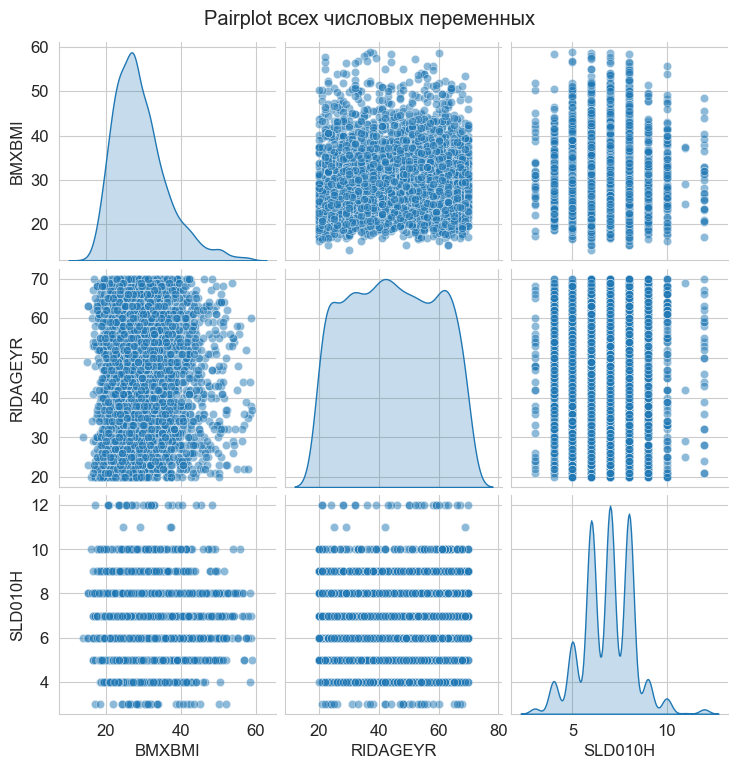

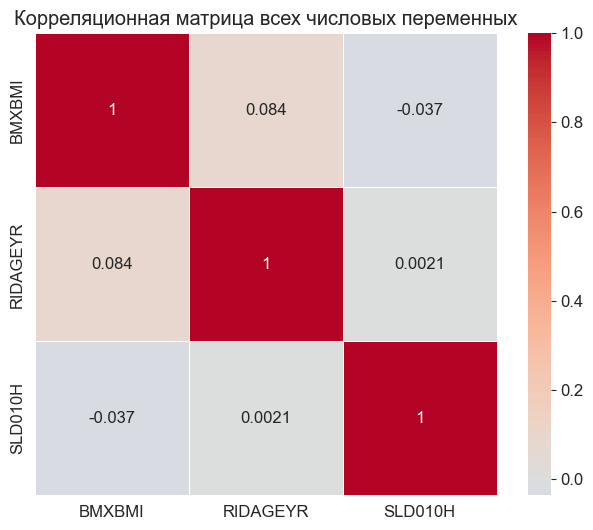

In [30]:
# Pairplot всех числовых переменных
numeric_df = df[['BMXBMI', 'RIDAGEYR', 'SLD010H']]
sns.pairplot(numeric_df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot всех числовых переменных', y=1.02)
plt.show()

# Heatmap корреляций (все числовые переменные)
corr_matrix_all = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_all, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Корреляционная матрица всех числовых переменных')
plt.show()
